#### Importing required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Loading

In this section, we load the required datasets for the analysis.

For the initial investigation, we start with the Orders dataset because it contains the delivery-related timestamps required to identify delayed orders.

In [3]:
orders_original=pd.read_csv("data/olist_orders_dataset.csv")
orders_original.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Initial Dataset Inspection
The goal of this step is to understand structure of the data,identifying important columns,inspect data types on the high level and to identify missing values if any.

In [4]:
orders_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


#### Observations
- The dataset contains 99441 entries

#### Data cleaning

In [ ]:
# Convert raw string timestamp to datetime objects so that we can perform time-delta calculations later
date_columns=["order_purchase_timestamp",\
              "order_approved_at",\
              "order_delivered_carrier_date",\
              "order_delivered_customer_date",\
              "order_estimated_delivery_date"]

for col in date_columns:
    orders_original[col]=pd.to_datetime(orders_original[col])

In [6]:
orders_original[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

#### Handling missing values

In [7]:
orders_original["order_delivered_customer_date"].isnull().sum()

np.int64(2965)

#### observation
- There are 2000 missing entries in the order_delivered_customer_date field.These likely represent specific order statuses, such as processed, shipped, cancelled, invoiced, or unrecorded orders.
- To determine whether an order was delivered on time or delayed, both the actual delivery date and the estimated delivery date must be available.
- Orders with missing delivery dates cannot be reliably classified as delayed or on-time. Therefore, these records will be excluded from the delivery delay analysis.

In [ ]:
orders=orders_original.dropna(subset=["order_delivered_customer_date"])
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


#### conclusion
- After removing orders with missing delivery dates, 96,476 orders remained for analysis.
- These records contain both actual and estimated delivery dates, allowing delivery performance to be evaluated accurately.

#### Feature Engineering: Delayed Order Flag
To evaluate delivery performance, a new feature called `is_delayed` is created.

Business Rule:
- If the actual delivery date is later than the estimated delivery date, the order is classified as delayed.
-  Otherwise, the order is classified as on-time.

This feature converts raw delivery timestamps into a business-friendly metric that can be used throughout the analysis.


In [ ]:
# Label orders as "Delayed" if actual delivery exceeds estimated delivery; other-wise "On-Time"
orders['is_delayed']=np.where(
    orders['order_delivered_customer_date']>orders['order_estimated_delivery_date'],
    "Delayed",
    "On-Time"
)

In [10]:
orders['is_delayed'].value_counts()

is_delayed
On-Time    88649
Delayed     7827
Name: count, dtype: int64

#### Observation

After creating the delayed order flag, the majority of orders were delivered on time.

However, 7,827 orders were delivered later than the estimated delivery date. To understand the scale of this issue, the delayed order percentage should be calculated rather than relying on raw counts alone.

#### KPI 1: Percentage of Delayed Orders

The delayed order rate measures the proportion of delivered orders that arrived later than the estimated delivery date.

Formula:

(Delayed Orders / Total Orders) × 100

This KPI helps quantify the scale of delivery performance issues within the marketplace.

In [11]:
(orders['is_delayed'].value_counts(normalize=True)*100).to_frame()

,proportion
is_delayed,
On-Time,91.887101
Delayed,8.112899


#### KPI Observation

Approximately 8% of delivered orders arrived later than the estimated delivery date, while around 92% were delivered on time.

This indicates that the overall delivery performance is relatively strong. However, delivery delays still affect a meaningful number of customers. Further analysis is required to determine whether delayed deliveries are associated with lower customer satisfaction and review scores.


##### Preparing Customer Satisfaction Data

The next step is to incorporate customer review data into the analysis.

Review scores will be used as a proxy for customer satisfaction. By linking review scores with delivery performance, we can evaluate whether delayed orders receive lower ratings than on-time orders.

In [ ]:
# Load raw order reviews data
reviews=pd.read_csv("data/olist_order_reviews_dataset.csv")

In [13]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [14]:
reviews.shape

(99224, 7)

In [15]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [ ]:
# Count number of null values in each column
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

#### review dataset observation

The reviews dataset contains 99,224 customer reviews.

For the current analysis, the most important fields are:

- order_id: Used to connect reviews table with orders table.
- review_score: Represents customer satisfaction.

No missing values were found in the review_score column, making it suitable for customer satisfaction analysis.

In [17]:
# Count how many orders are missing customer reviews (Expects 0 if all are reviewed)
len(orders.loc[~orders['order_id'].isin(reviews['order_id'])])
# 646 orders don't have customer review

646

In [ ]:
# merge orders data and order reviews data for customer_satisfaction_analysis
orders_reviews=orders.merge(reviews,on="order_id",how="inner")

In [19]:
print(orders_reviews.shape[0])
print(orders['order_id'].nunique())
print(orders_reviews['order_id'].nunique())
# IMP observation there were 646 orders which was without review
# after merging there are 96359 records but it should be 95830 , lets inspect review table

96359
96476
95830


In [20]:
print(len(reviews['order_id']))
print(reviews['order_id'].nunique())
# order_id key in review table might have some duplicates,lets verify 

99224
98673


In [21]:
reviews['order_id'].duplicated().sum()
# there are 551 duplicate order_id,which means each order has multiple review

np.int64(551)

In [ ]:
reviews[reviews.duplicated(subset=['order_id'],keep=False)].\
    sort_values(by=['order_id']).head(10)
# There are multiple reviews for each order

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


In [ ]:
# Convert raw timestamp to datetime object to find latest review score for each order
reviews[["review_creation_date","review_answer_timestamp"]]=reviews[["review_creation_date",\
    "review_answer_timestamp"]]\
    .apply(pd.to_datetime)

In [ ]:
reviews_cleaned=reviews.sort_values(by=['order_id',"review_answer_timestamp"])

In [ ]:
# keep only latest review score and remove initial review scores
reviews_cleaned=reviews.drop_duplicates(subset=['order_id'],keep='last')

In [26]:
reviews_cleaned['order_id'].duplicated().sum()

np.int64(0)

In [27]:
orders_reviews=orders.merge(reviews_cleaned,on='order_id',how='inner')

In [28]:
orders_reviews[['order_id','is_delayed','review_score']].head()

,order_id,is_delayed,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,On-Time,4
1,53cdb2fc8bc7dce0b6741e2150273451,On-Time,4
2,47770eb9100c2d0c44946d9cf07ec65d,On-Time,5
3,949d5b44dbf5de918fe9c16f97b45f8a,On-Time,5
4,ad21c59c0840e6cb83a9ceb5573f8159,On-Time,5


In [29]:
delayed_means=orders_reviews.groupby(by="is_delayed")['review_score'].mean().round(2).reset_index().sort_values(by="review_score",ascending=False)
delayed_means

,is_delayed,review_score
1,On-Time,4.29
0,Delayed,2.57


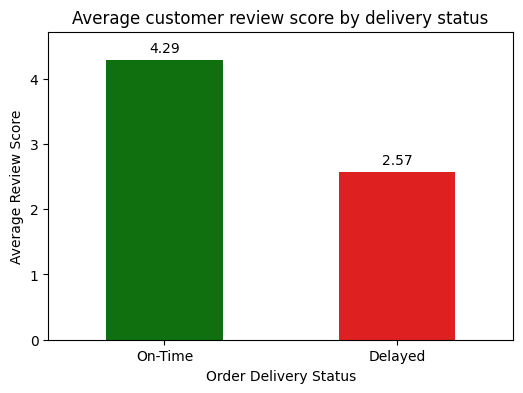

In [30]:
plt.figure(figsize=(6,4))
sns.barplot(data=delayed_means,x="is_delayed",y="review_score",hue="is_delayed",palette=(['green','red']),width=0.5)
plt.xlabel("Order Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Average customer review score by delivery status")
plt.margins(y=0.1)
for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=3)
plt.show()


**Insight: Delivery Performance and Customer Satisfaction**

The analysis shows a clear relationship between delivery performance and customer review scores.

Orders delivered on or before the estimated delivery date received an average review score of 4.29, while delayed orders received an average review score of 2.57.

This finding suggests that delivery performance is strongly associated with customer satisfaction. Lower review scores on delayed orders may negatively influence customer trust, repeat purchases, brand reputation, and long-term customer retention. Although this analysis does not establish causation, it highlights delivery delays as a key area requiring further investigation.


----

**The Next Question:** *Why are these delays happening?*

To provide actionable recommendations to the business, we need to locate the operational bottlenecks. We will conduct a **Root Cause Analysis (RCA)**.

Root Cause Analysis Objectives:

The next phase of the project investigates the following questions:

1. Which stage contributes more to delivery delays: seller processing time or carrier transit time?
2. How does delivery distance (inter-state vs. intra-state) affect carrier transit time and delivery delays?
3. Which product categories have the highest delayed delivery rate?
4. Which sellers consistently experience the highest delayed delivery rates?

By answering these questions, the project moves beyond measuring business impact and focuses on identifying actionable operational improvements that can reduce delivery delays and enhance the customer experience.

##### **Business question :** Which stage contributes more to delivery delays: seller processing time or carrier transit time?

The objective of this analysis is to compare seller processing time and carrier transit time to determine which operational stage contributes more to delivery delays. The findings will help the business identify where operational improvements should be prioritized.



In [31]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delayed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,On-Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,On-Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,On-Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,On-Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,On-Time


In [32]:
orders.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
is_delayed                        0
dtype: int64

In [33]:
(orders["order_delivered_carrier_date"] - orders["order_approved_at"])/pd.Timedelta(days=1)

0        2.366493
1        0.462882
2        0.204595
3        3.745833
4        0.893113
           ...   
99436    1.058310
99437    1.425058
99438    1.241782
99439    3.749097
99440    0.452442
Length: 96476, dtype: float64

In [34]:
# creating new features: "seller_processing_days" & "carrier_transit_days"

orders["seller_processing_days"]=(((orders["order_delivered_carrier_date"]-orders["order_approved_at"])).dt.total_seconds())/(24*3600)

orders['carrier_transit_days']=((orders["order_delivered_customer_date"]-orders["order_delivered_carrier_date"]).dt.total_seconds())/(24*3600)

#### Work in progress : Validating the seller processing days and carrier transit days features before metric calculation

In [35]:
orders[
    [
        "seller_processing_days",
        "carrier_transit_days"
    ]
].describe()

,seller_processing_days,carrier_transit_days
count,96461.000000,96475.000000
mean,2.799283,9.330547
std,3.537573,8.760122
min,-171.219005,-16.096169
25%,0.874363,4.099948
50%,1.815856,7.099769
75%,3.575208,12.029115
max,125.762569,205.190972


In [36]:

# Count of negative values in seller_processing_days column
orders["seller_processing_days"].lt(0).sum()



np.int64(1350)

In [37]:
# Statistical information about negative values only of seller_processing_days
orders.loc[
    orders["seller_processing_days"] < 0,
    "seller_processing_days"
].describe()

count    1350.000000
mean       -1.029290
std         4.818968
min      -171.219005
25%        -1.081389
50%        -0.714988
75%        -0.058869
max        -0.000243
Name: seller_processing_days, dtype: float64

In [38]:
# Look at first few negative values
orders.loc[
    orders["seller_processing_days"] < 0,
    "seller_processing_days"
].sort_values().head()

25883   -171.219005
14562     -9.372083
46163     -9.341262
98710     -9.163843
41592     -9.115104
Name: seller_processing_days, dtype: float64

In [39]:
# Negative values/days between -1 day and 0 days
orders[
    (orders["seller_processing_days"] < 0) &
    (orders["seller_processing_days"] >= -1)
].shape[0]

897

In [40]:
# Negative values/days less than -1 day
orders[
    orders["seller_processing_days"] < -1
].sort_values(by="seller_processing_days").head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delayed,seller_processing_days,carrier_transit_days
25883,7c48bb55e8e4f7e56d412e9653db37bc,34ef6181341eb36c47fd601c46878f00,delivered,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,On-Time,-171.219005,178.270660
14562,1fab4ac9d85079b3da72a11475ae1685,f831c1fa80308975ec2b58e4877328e0,delivered,2017-09-01 19:04:22,2017-09-13 22:06:11,2017-09-04 13:10:23,2017-09-08 20:13:03,2017-09-20,On-Time,-9.372083,4.293519
46163,0184d4ddb259e1a4cfc2871888cf97b8,09425ea1839abf2f0d289a0ff453fa21,delivered,2017-09-01 20:04:28,2017-09-13 22:17:15,2017-09-04 14:05:50,2017-09-09 15:12:44,2017-09-20,On-Time,-9.341262,5.046458
98710,1378f9601350615613cc8832d6789c5d,988126b4ddf725d9724e4318872ea2ae,delivered,2017-09-01 20:28:02,2017-09-13 22:03:51,2017-09-04 18:07:55,2017-09-13 22:24:46,2017-09-29,On-Time,-9.163843,9.178368
41592,8554cb37f7158cb0b082a841d24a4589,788e845925ff64c9df5d8ba40e28cf50,delivered,2017-09-01 18:40:44,2017-09-13 21:58:04,2017-09-04 19:12:19,2017-09-08 20:07:45,2017-10-02,On-Time,-9.115104,4.038495


In [41]:
# Number of negative values/days in carrier delivery time
orders['carrier_transit_days'].lt(0).sum()

np.int64(23)

In [42]:
# Statistical information of negative values of carrier_delivery time
orders.loc[
    orders["carrier_transit_days"] < 0,
    "carrier_transit_days"
].describe()

count    23.000000
mean     -3.268964
std       3.721170
min     -16.096169
25%      -5.364959
50%      -1.661019
75%      -0.972431
max      -0.016181
Name: carrier_transit_days, dtype: float64

In [43]:

orders.loc[
    (orders["carrier_transit_days"] < 0)&(orders['carrier_transit_days']>-1),
    [
        "order_id",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "carrier_transit_days"
    ]
].sort_values("carrier_transit_days").head()

,order_id,order_delivered_carrier_date,order_delivered_customer_date,carrier_transit_days
58428,fbffbaaa30f4077e87ec6acdb835b278,2017-08-04 20:04:17,2017-08-03 20:30:00,-0.982141
22520,b27af682321527a6349f1761eb3f360c,2017-06-27 14:51:54,2017-06-26 15:45:35,-0.962720
95634,f688669f48063536e082bb32d634cd46,2016-10-21 18:02:40,2016-10-20 20:33:27,-0.895289
21338,8c78d01de3a9009e23d6877a7cc9be20,2016-10-26 11:41:53,2016-10-25 17:51:46,-0.743137
19268,5f9d46795c3126674e52becb3a1a517f,2017-07-20 23:03:42,2017-07-20 18:52:41,-0.174317


In [44]:
# Filtering out rows with negative values in seller and carrier delivery days column
invalid_rows = (orders['seller_processing_days'] < 0) | (orders['carrier_transit_days'] < 0)

# No. of negative value in the data
print(f"Total anomalous rows identified and dropped: {invalid_rows.sum()} ({invalid_rows.sum()/len(orders)*100:.2f}%)")

Total anomalous rows identified and dropped: 1373 (1.42%)


In [45]:
# Filtering out valid data
cleaned_df=orders[~invalid_rows].copy()

# Calculating metric for sellers delivery time and carriers delivery time
analysis_q1=cleaned_df.groupby("is_delayed")[["seller_processing_days","carrier_transit_days"]].mean().round(2).reset_index()
analysis_q1

,is_delayed,seller_processing_days,carrier_transit_days
0,Delayed,5.35,25.68
1,On-Time,2.63,7.91


In [46]:
# Reshaping data from wide to long format for better visualization
melted_df = pd.melt(analysis_q1, id_vars=['is_delayed'], 
                    value_vars=['seller_processing_days', 'carrier_transit_days'],
                    var_name='Fulfillment_Stage', value_name='Average_Days')
melted_df

,is_delayed,Fulfillment_Stage,Average_Days
0,Delayed,seller_processing_days,5.35
1,On-Time,seller_processing_days,2.63
2,Delayed,carrier_transit_days,25.68
3,On-Time,carrier_transit_days,7.91


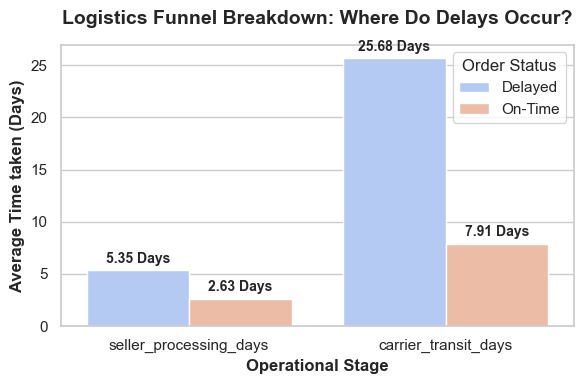

In [47]:
# Plotting
plt.figure(figsize=(6,4))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=melted_df, x='Fulfillment_Stage', y='Average_Days', hue='is_delayed', palette='coolwarm')

# Visual styling
plt.title('Logistics Funnel Breakdown: Where Do Delays Occur?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Operational Stage', fontsize=12, fontweight='bold')
plt.ylabel('Average Time taken (Days)', fontsize=12, fontweight='bold')
plt.legend(title='Order Status')

# Annotate values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f} Days', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Insight:
- Delayed orders are associated with a much larger increase in carrier transit time than seller processing time, suggesting that transportation and logistics are the primary operational bottlenecks
### Observation

Both seller processing time and carrier transit time increase for delayed orders compared with on-time deliveries. However, the magnitude of the increase differs substantially between the two operational stages.

Seller processing time increases from **2.63 days** for on-time orders to **5.35 days** for delayed orders, an increase of approximately **2.72 days**.

Carrier transit time increases from **7.91 days** for on-time orders to **25.68 days**, an increase of approximately **17.77 days**.

This indicates that while sellers contribute to delivery delays, the increase in carrier transit time is considerably larger.

### Business Impact

The findings suggest that transportation and logistics represent the primary operational bottleneck associated with delayed deliveries. Since earlier analyses showed that delayed deliveries are associated with significantly lower customer review scores, improving carrier performance could have a meaningful impact on customer satisfaction and the overall delivery experience.

### Recommendation

The business should investigate the logistics network to identify the reasons behind prolonged carrier transit times. Potential areas for further analysis include geographic delivery routes, regional carrier performance, warehouse-to-customer transit efficiency, and high-delay shipping lanes.

Although seller processing time also increases for delayed orders, the much larger increase in carrier transit time indicates that logistics improvements should be prioritized before optimizing seller dispatch processes.


---

The previous analysis identified carrier transit as the primary operational bottleneck associated with delayed deliveries.

**Next Question** : *Why is the carrier network collapsing?* 

Brazil's massive geographic footprint covers vastly different regional infrastructures. To understand if these transit spikes are driven by physical distance and cross-country fulfillment friction, we will isolate and analyze **Inter-State (cross-border)** vs. **Intra-State (local)** delivery performance.

##### **Business Question:** Does delivery distance (inter-state vs. intra-state) influence carrier transit delays?
**Busines Objective** : 

Orders where the seller and customer are located in different states (inter-state) are expected to travel longer distances than orders fulfilled within the same state (intra-state). Understanding this relationship can help the business optimize logistics operations, improve carrier allocation, and set more accurate delivery expectations.

In [48]:
# Loading required datasets
customers=pd.read_csv("data/olist_customers_dataset.csv")
order_items=pd.read_csv("data/olist_order_items_dataset.csv")
sellers=pd.read_csv("data/olist_sellers_dataset.csv")

In [49]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [50]:
# Basic inspection of customers dataset
customers_state=customers.copy()
customers_state.drop(columns=['customer_unique_id','customer_zip_code_prefix','customer_city'],inplace=True) # Drop unwanted columns
customers_state.head() # Extracted only columns which is needed for this analysis

,customer_id,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,SP
1,18955e83d337fd6b2def6b18a428ac77,SP
2,4e7b3e00288586ebd08712fdd0374a03,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,SP


In [51]:
# High level information about customers dataset
customers_state.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     99441 non-null  str  
 1   customer_state  99441 non-null  str  
dtypes: str(2)
memory usage: 1.5 MB


In [52]:
# Check Null Values
customers_state.isnull().sum()

customer_id       0
customer_state    0
dtype: int64

In [53]:
# Check duplicates
customers_state.duplicated().sum()

np.int64(0)

In [54]:
# Basic inspection of order_items dataset
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [55]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [56]:
# To get seller id for each order this table will act as a junction table to connect with sellers table
# We only need order_id and seller_id from this table as they will act as a joining keys 

order_items_junc=order_items[['order_id','seller_id']] 
order_items_junc.head()

,order_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87


In [57]:
order_items_junc.shape

(112650, 2)

In [58]:
# Check null values
order_items_junc.isnull().sum()

order_id     0
seller_id    0
dtype: int64

In [59]:
# Check duplicates
order_items_junc.duplicated().sum()

np.int64(12640)

In [60]:
order_items_junc.drop_duplicates(inplace=True)

In [61]:
order_items_junc.duplicated().sum() # No duplicates after dropping it

np.int64(0)

In [62]:
sellers_state=sellers[['seller_id','seller_state']]
sellers_state.head()

,seller_id,seller_state
0,3442f8959a84dea7ee197c632cb2df15,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,SP


In [63]:
sellers_state.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   seller_id     3095 non-null   str  
 1   seller_state  3095 non-null   str  
dtypes: str(2)
memory usage: 48.5 KB


In [64]:
sellers_state['seller_id'].nunique()

3095

In [65]:
order_items_junc[order_items_junc['order_id'].isin(cleaned_df['order_id'])]

,order_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87
...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,b8bc237ba3788b23da09c0f1f3a3288c
112646,fffcd46ef2263f404302a634eb57f7eb,f3c38ab652836d21de61fb8314b69182
112647,fffce4705a9662cd70adb13d4a31832d,c3cfdc648177fdbbbb35635a37472c53
112648,fffe18544ffabc95dfada21779c9644f,2b3e4a2a3ea8e01938cabda2a3e5cc79


In [66]:
# Validate orders and order_items table beofore joining
# cleaned_df.merge(order_items_junc,on='order_id',how='inner',validate='1:1')
# It raises error, because the relation is not "1:1"(one-to-one) its "1:m"(one-to-many)

In [67]:
# Lets roughly join the tables and check

df_geo=cleaned_df.merge(customers_state,on='customer_id',how='left')
df_geo=df_geo.merge(order_items_junc,on='order_id',how='inner')
df_geo=df_geo.merge(sellers_state,on='seller_id',how='inner')


In [68]:
df_geo[['order_id','customer_id','seller_id','customer_state','seller_state','carrier_transit_days','is_delayed']]

,order_id,customer_id,seller_id,customer_state,seller_state,carrier_transit_days,is_delayed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,3504c0cb71d7fa48d967e0e4c94d59d9,SP,SP,6.062650,On-Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,289cdb325fb7e7f891c38608bf9e0962,BA,SP,12.039410,On-Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,4869f7a5dfa277a7dca6462dcf3b52b2,GO,SP,9.178113,On-Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,66922902710d126a0e7d26b0e3805106,RN,MG,9.450498,On-Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2c9e548be18521d1c43cde1c582c6de8,SP,SP,1.937824,On-Time
...,...,...,...,...,...,...,...
96381,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,e24fc9fcd865784fb25705606fe3dfe7,SP,SP,7.159699,On-Time
96382,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,1f9ab4708f3056ede07124aad39a2554,SP,SP,20.760579,On-Time
96383,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,d50d79cb34e38265a8649c383dcffd48,BA,SP,23.605451,On-Time
96384,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,a1043bafd471dff536d0c462352beb48,RJ,MG,13.331840,On-Time


In [69]:
print(f"No of orders which has mulitple sellers per order:{df_geo['order_id'].value_counts().gt(1).sum()}")
print(f"No of orders which has mulitple sellers per order in perc:{round((1223/95103)*100)}%")
print(f"Total No of unique order_id:{df_geo['order_id'].nunique()}")

No of orders which has mulitple sellers per order:1223
No of orders which has mulitple sellers per order in perc:1%
Total No of unique order_id:95103


In [70]:
# Since only 1.3% of orders involve multiple sellers, these orders were excluded from the geographical routing analysis to
#  maintain a one-to-one relationship between customer, seller, and delivery record.

counts = df_geo["order_id"].value_counts()
duplicate_ids = counts[counts > 1].index

counts=df_geo['order_id'].value_counts()
multiple_seller_order = counts[counts > 1].index
df_geo=df_geo[~df_geo['order_id'].isin(multiple_seller_order)]

##### <font color='navy blue'>**Createing New Feature**</font>

**`route_type`**=**`"Intra_state"`** if seller and customer are in the same state otherwise **`"Inter_state"`** 

In [71]:
df_geo["route_type"]=np.where(df_geo['customer_state']==df_geo['seller_state'],"Intra_state","Inter_state")

In [72]:
# Baseline Analysis: Impact of Route Type on Overall Carrier Transit Days and Delay Rates"

geo_analysis=df_geo.copy()
geo_analysis['is_delayed']=geo_analysis['is_delayed'].map({'On-Time':False,'Delayed':True})

analysis_q2=geo_analysis.groupby('route_type').agg(
    total_orders=('order_id', 'nunique'),
    delayed_orders=('is_delayed', 'sum'),
    avg_carrier_transit_days=('carrier_transit_days', 'mean')
).reset_index()
analysis_q2['delay_rate']=round(analysis_q2["delayed_orders"] / analysis_q2["total_orders"] * 100,2)
analysis_q2

,route_type,total_orders,delayed_orders,avg_carrier_transit_days,delay_rate
0,Inter_state,60133,5687,11.957360,9.46
1,Intra_state,33747,2089,4.829309,6.19


In [73]:
df_plot_q2=analysis_q2[['route_type','delay_rate','avg_carrier_transit_days']]
df_plot_q2

,route_type,delay_rate,avg_carrier_transit_days
0,Inter_state,9.46,11.957360
1,Intra_state,6.19,4.829309


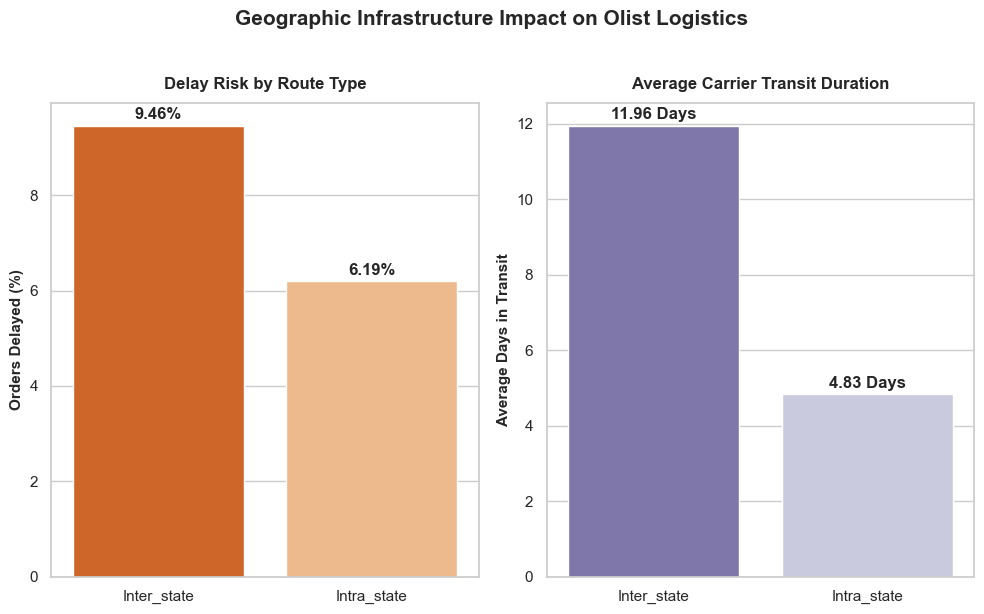

In [74]:
# Create a 1-row, 2-column subplot structure
fig, axes = plt.subplots(1, 2, figsize=(10,6))
sns.set_theme(style="whitegrid")

# Plot 1: Delay Rate Percentage
ax1 = sns.barplot(data=df_plot_q2,x='route_type', y='delay_rate', ax=axes[0],hue='route_type',legend=False,palette='Oranges_r')
axes[0].set_title('Delay Risk by Route Type', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Orders Delayed (%)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('', fontsize=11)

# Annotate Plot 1
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Plot 2: Average Carrier Transit Days
ax2 = sns.barplot(data=df_plot_q2,
                  x='route_type', y='avg_carrier_transit_days', ax=axes[1],hue='route_type',legend=False,palette='Purples_r')
axes[1].set_title('Average Carrier Transit Duration', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Average Days in Transit', fontsize=11, fontweight='bold')
axes[1].set_xlabel('', fontsize=11)

# Annotate Plot 2
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.2f} Days', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.suptitle('Geographic Infrastructure Impact on Olist Logistics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [75]:
# df_geo[df_geo['is_delayed']=='Delayed'].groupby('route_type')['carrier_transit_days'].mean().reset_index()
# # Lets see, When a package is late, does geography make it even worse?"
# df_geo[df_geo['is_delayed']=='Delayed'].groupby('route_type')['carrier_transit_days'].mean().reset_index()

In [76]:
# Deep Dive analysis : Compare avg carrier transit days for on-time delivery vs delayed delivery

# Group by BOTH route type AND delay status to get the full picture
geo_matrix = df_geo.groupby(['route_type', 'is_delayed'])['carrier_transit_days'].mean().unstack()
# Clean up the column headers for display
geo_matrix.columns = ['Delayed Avg Transit (Days)','On-Time Avg Transit (Days)']
print("--- The Compounding Impact of Geography and Delays ---")
print(geo_matrix)

--- The Compounding Impact of Geography and Delays ---
             Delayed Avg Transit (Days)  On-Time Avg Transit (Days)
route_type                                                         
Inter_state                   30.124184                   10.060131
Intra_state                   13.622125                    4.249102


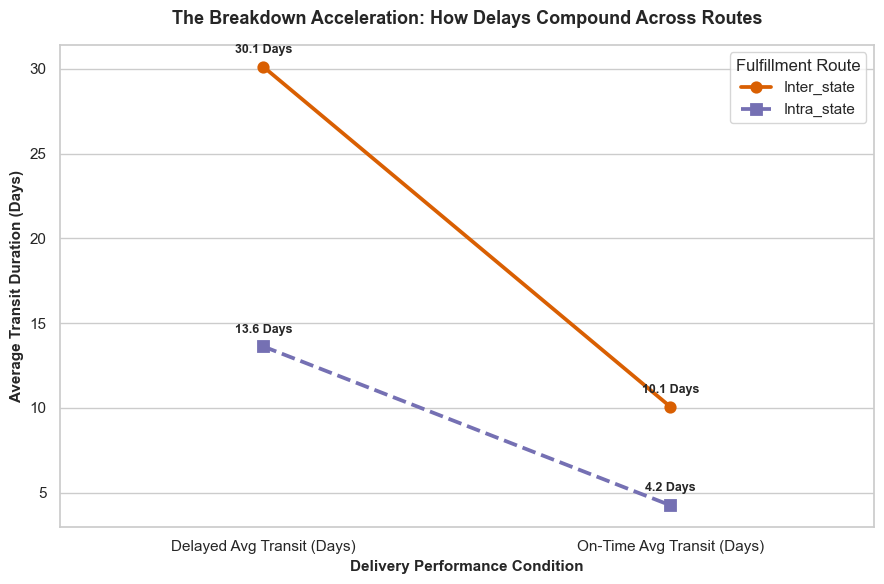

In [77]:
# Reset index on your matrix to make it easy to plot
df_matrix_plot = geo_matrix.reset_index().melt(
    id_vars='route_type', 
    var_name='Delivery_Condition', 
    value_name='Transit_Days'
)

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Create a point plot showing how transit time jumps
ax = sns.pointplot(
    data=df_matrix_plot, 
    x='Delivery_Condition', 
    y='Transit_Days', 
    hue='route_type',
    markers=["o", "s"], 
    linestyles=["-", "--"],
    palette=['#d95f02', '#7570b3']
)

plt.title('The Breakdown Acceleration: How Delays Compound Across Routes', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Average Transit Duration (Days)', fontsize=11, fontweight='bold')
plt.xlabel('Delivery Performance Condition', fontsize=11, fontweight='bold')
plt.legend(title='Fulfillment Route')

# Add value labels to points
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        if not np.isnan(y):
            ax.annotate(f'{y:.1f} Days', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Observation

Orders fulfilled across different states require substantially longer carrier transit times than orders fulfilled within the same state.

Across all deliveries, inter-state shipments take an average of **11.96 days**, compared with **4.83 days** for intra-state shipments.

Among delayed orders, the difference becomes even more pronounced. Delayed inter-state shipments require an average of **30.12 days**, whereas delayed intra-state shipments average **13.62 days**.

Additionally, inter-state orders account for a higher proportion of delayed deliveries than intra-state orders, indicating that longer shipping routes are associated with greater logistical challenges.

### Business Impact

These findings suggest that geographic distance is an important operational factor associated with carrier transit performance. Longer shipping routes expose deliveries to more transportation stages, regional handoffs, and logistical complexity, increasing both transit duration and the likelihood of delivery delays.

### Recommendation

The business should prioritize improving logistics for inter-state shipments by evaluating carrier performance across long-distance routes, optimizing distribution center allocation, and identifying high-delay shipping corridors. For customers located farther from fulfillment centers, the business may also consider providing more realistic delivery estimates to better manage customer expectations.


----

### 📦 Transition: Moving from Where to What

**What We Know:** Question 2 clearly mapped the geographic realities of the Olist logistics network. We proved that cross-border, Inter-State shipping loops act as massive systemic stressors—tripling carrier transit times and accelerating delivery delays to nearly a full month under failure conditions.

**The Next Question:** *Does geography tell the whole story?* Logistics isn't just about distance; it's also about the **physical properties** of what is being shipped. A small beauty product or smartphone can easily be dispatched via standard parcel carriers. However, bulky furniture, home appliances, or fragile electronics require specialized handling, heavy freight coordination, and separate dispatch pipelines. 

To determine if certain physical items are structurally prone to bottlenecks, we will step down into

 **Question 3: Product Category Analysis** and isolate which product types suffer from the highest delayed delivery rates.

To answer this business question we need following datasets:
1) orders dataset
2) order_items dataset
3) products dataset
4) product_category_name_translation

We have orders and order_items dataset, lets import other dataset too.

In [78]:
# Import essential data for this analysis
products=pd.read_csv("data/olist_products_dataset.csv")
product_category_name_translation=pd.read_csv("data/product_category_name_translation.csv")

In [79]:
# First few rows of products dataset
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [80]:
# We only need product_id and product_category_name columns for this analysis
products_id=products.copy()
products_id=products_id[['product_id','product_category_name']]
products_id.head()

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas


In [81]:
products_id.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   product_id             32951 non-null  str  
 1   product_category_name  32341 non-null  str  
dtypes: str(2)
memory usage: 515.0 KB


In [82]:

products_id.isnull().sum()

product_id                 0
product_category_name    610
dtype: int64

In [83]:
# Check duplicates
products_id.duplicated().sum()

np.int64(0)

In [84]:
product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [85]:
product_category_name_translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [86]:
product_category_name_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [87]:
product_category_name_translation.duplicated().sum()

np.int64(0)

In [101]:
cleaned_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delayed,seller_processing_days,carrier_transit_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,On-Time,2.366493,6.062650
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,On-Time,0.462882,12.039410
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,On-Time,0.204595,9.178113
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,On-Time,3.745833,9.450498
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,On-Time,0.893113,1.937824


In [ ]:
print(cleaned_df[[]]['order_id'].nunique())
print(order_items[['order_id','product_id']]['order_id'].nunique())

95103
98666


In [263]:
df_prod=cleaned_df[['order_id','is_delayed']].merge(order_items[['order_id','product_id']],how='left',on='order_id')
df_prod=df_prod.merge(products_id,how='left',on='product_id')
df_prod=df_prod.merge(product_category_name_translation,how='left',on='product_category_name')
df_prod.head()

,order_id,is_delayed,product_id,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,On-Time,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,On-Time,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,On-Time,aa4383b373c6aca5d8797843e5594415,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,On-Time,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,On-Time,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,stationery


In [264]:
# Lets rename product_category columns for better understanding
df_prod.rename(
    columns={
        "product_category_name":"product_category_name_portuguese",
        "product_category_name_english":"product_category"
    },inplace=True
)

In [265]:
df_prod.duplicated().sum()

np.int64(9870)

In [266]:
df_prod.drop_duplicates(inplace=True)

In [267]:
df_prod.duplicated().sum()

np.int64(0)

In [268]:
df_prod.isnull().sum()

order_id                               0
is_delayed                             0
product_id                             0
product_category_name_portuguese    1391
product_category                    1411
dtype: int64

In [269]:
# Lets fill the null values
df_prod['product_category']=df_prod['product_category'].fillna(df_prod['product_category_name_portuguese'])

In [270]:
df_prod['product_category']=df_prod['product_category'].fillna('unspecified_category')

In [271]:
df_prod.isnull().sum()

order_id                               0
is_delayed                             0
product_id                             0
product_category_name_portuguese    1391
product_category                       0
dtype: int64

In [281]:
## Lets calculate delay rate for each product_category

df_prod['is_delayed']=df_prod['is_delayed'].map({"On-Time":False,"Delayed":True})

prod_analysis=df_prod.groupby('product_category').agg(
    total_orders=('order_id','count'),
    delayed_item_orders=('is_delayed','sum')
).reset_index()

# Create delay_rate column
prod_analysis['delay_rate']=round((prod_analysis['delayed_item_orders']/prod_analysis['total_orders'])*100,2)

prod_analysis.head()

,product_category,total_orders,delayed_item_orders,delay_rate
0,agro_industry_and_commerce,176,9,5.11
1,air_conditioning,243,10,4.12
2,art,192,15,7.81
3,arts_and_craftmanship,23,2,8.70
4,audio,344,45,13.08


In [325]:
significant_categories=prod_analysis[prod_analysis['total_orders']>100]
top_10_delayed_categories=significant_categories.sort_values(by='delay_rate',ascending=False).head(10)
top_10_delayed_categories

,product_category,total_orders,delayed_item_orders,delay_rate
4,audio,344,45,13.08
33,fashion_underwear_beach,118,15,12.71
10,books_technical,251,28,11.16
47,home_confort,394,42,10.66
12,christmas_supplies,126,13,10.32
36,food,436,45,10.32
26,electronics,2502,247,9.87
72,unspecified_category,1391,128,9.20
18,construction_tools_lights,241,22,9.13
6,baby,2817,257,9.12


### Data Validation

Some product categories contain only a small number of orders. Categories with very low order volumes can produce misleading delay rates. For example, a category with only two orders where both were delayed would show a delay rate of 100%, but this would not represent a reliable operational trend.

To improve the statistical reliability of the comparison, only product categories with at least **100 unique orders** were included in the final analysis. This reduces the impact of small sample sizes and ensures that the reported delay rates are based on meaningful order volumes.


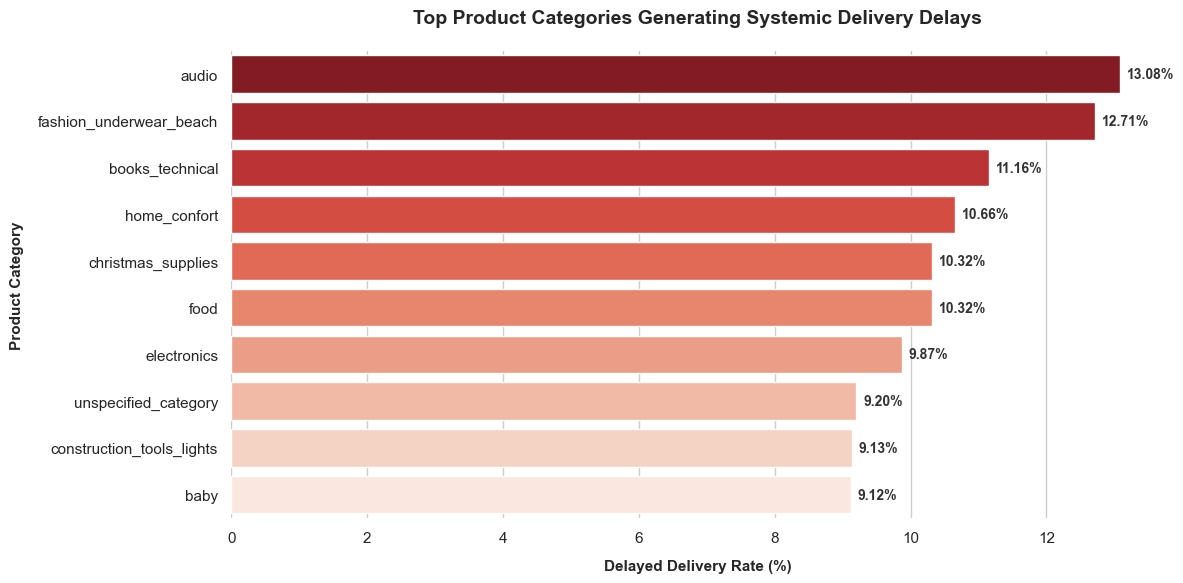

In [334]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='delay_rate', 
    y='product_category',
    hue='product_category',
    data=top_10_delayed_categories, 
    palette='Reds_r' # Beautiful gradient shading from worst to least worst
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width +0.1, p.get_y() + p.get_height()/2, f'{width:.2f}%', 
            va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')


plt.title('Top Product Categories Generating Systemic Delivery Delays', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Delayed Delivery Rate (%)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Product Category', fontsize=11, fontweight='bold', labelpad=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


### Observation

After filtering for product categories with at least **100 unique orders**, several categories were found to have noticeably higher delayed delivery rates than the overall average.

The highest delayed delivery rates were observed in **Audio (13.08%)**, **Fashion Underwear & Beach (12.71%)**, **Technical Books (11.16%)**, **Home Comfort (10.66%)**, and **Christmas Supplies (10.32%)**.

Although categories such as **Electronics** and **Baby Products** do not have the highest delay rates, they represent substantially larger order volumes. As a result, even moderate delay rates in these categories can affect a large number of customers.

### Business Impact

The findings indicate that delivery performance is not uniform across product categories. Some categories consistently experience higher delay rates, suggesting that product characteristics or fulfillment requirements may influence logistics performance.

Higher delay rates in high-volume categories can have a disproportionate impact on customer experience because a larger number of customers are affected.

### Recommendation

The business should investigate the operational characteristics of high-delay categories to determine whether specialized fulfillment strategies are required. Factors such as product size, fragility, seasonal demand, storage requirements, and carrier selection should be evaluated.

The categories identified in this analysis should be prioritized for operational review to reduce delivery delays and improve customer satisfaction.


### Final takeaway:

"The analyses collectively indicate that delivery delays are associated with lower customer satisfaction,with carrier transit emerging as the primary operational bottleneck.Geographic shipping routes and specific product categories further contribute to prolonged delivery times, providing the business with clear areas for targeted operational improvements."